# EDA

- Découvrir notre data pour les préparer pour la suite
- Par exemple en Machine-Learning, On ne veux aucune valeur nulle / textuelle

In [51]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 




In [52]:
df = pd.read_csv(r'Data\stroke.csv', index_col="id").sort_index()
display(df.head())




,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,,,,,,,,,,,
67,Female,17.0,0,0,No,Private,Urban,92.97,NaN,formerly smoked,0
77,Female,13.0,0,0,No,children,Rural,85.81,18.6,Unknown,0
84,Male,55.0,0,0,Yes,Private,Urban,89.17,31.5,never smoked,0
91,Female,42.0,0,0,No,Private,Urban,98.53,18.5,never smoked,0
99,Female,31.0,0,0,No,Private,Urban,108.89,52.3,Unknown,0


In [53]:
df.describe().T  # Tiens, mon max du bmi et glucose_lvl semblent vachement haut vis-à-vis de ma moyenne

,count,mean,std,min,25%,50%,75%,max
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


In [54]:
df.info()


<class 'pandas.DataFrame'>
Index: 5110 entries, 67 to 72940
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   Residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   str    
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 479.1 KB


#### Lorsque l'on vafaire du ML, dans de nombreux cas on va faire de l'apprentissage supervisé donc avoir une Target et des features, lors de l'EDA on ne les sépare pas.

- Après notre info(), on remarque qu'on a des strings donc a premier abord, on est sur du qualitatif.
- Ce n'est pas sur ça qu'il faut se baser mais cela donne une première impression

1. Je remarque des strings
2. Je remarque des valeurs null

In [55]:
# Check des valeurs nulles
df.isna().sum() # Savoir qu'il y'en a ne me suffit pas, où sont elles ?

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

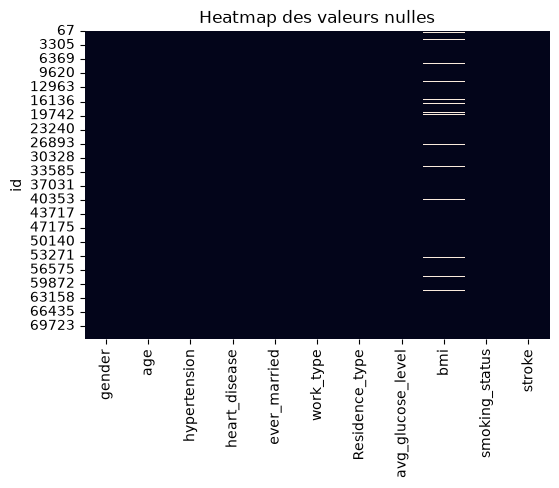

In [56]:
plt.figure(figsize=(6,4))                # Déclarer une fig (carré_blanc/screen)  (structure, déclarer, ajouter/peupler, afficher)
plt.title("Heatmap des valeurs nulles")  # Titre
sns.heatmap(df.isna(), cbar=False)       # Graphique de Seaborn   cbar = barre de l'intensité des couleurs   
plt.show()                               # J'affiche la figure


                                             ^
                                             |
## Création d'une Heatmap 
- Me permet de voir OU sont les valeurs manquantes

In [57]:
for col in df.columns :
    display(df[col].value_counts())

    # Je fais une value count pour séparer ce que est quantitatif de qualitatif

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

age
78.00    102
57.00     95
52.00     90
54.00     87
51.00     86
        ... 
0.16       3
0.48       3
1.40       3
0.40       2
0.08       2
Name: count, Length: 104, dtype: int64

hypertension
0    4612
1     498
Name: count, dtype: int64

heart_disease
0    4834
1     276
Name: count, dtype: int64

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

...

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

avg_glucose_level
93.88     6
72.49     5
91.68     5
83.16     5
91.85     5
         ..
129.54    1
90.57     1
172.33    1
62.55     1
102.92    1
Name: count, Length: 3979, dtype: int64

bmi
28.7    41
28.4    38
27.6    37
26.7    37
26.1    37
        ..
64.8     1
51.0     1
64.4     1
54.1     1
61.6     1
Name: count, Length: 418, dtype: int64

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

stroke
0    4861
1     249
Name: count, dtype: int64

### Analyse de mon value_count

- Je remarque une valeur other dans gender => 1 valeurs, pas assez représentatif donc il va sauté

- Beaucoup de colonnes catégoriques (donc on va partir sur de la classification plutot que de la régression)
- La majorité des colonnes sont représentée en int, Or c'est du catégorique.

In [58]:
cont_features = df[['age','avg_glucose_level',"bmi"]]  # Récupération des colonnes continues
cat_features = df.drop(columns=['age','avg_glucose_level',"bmi"]) # Récupération des colonnes catégoriques.

- On sépare les features continues et catégoriques car on ne va pas les traiter de la même manière

## Analyse univariée (analyse des features 1 par 1)

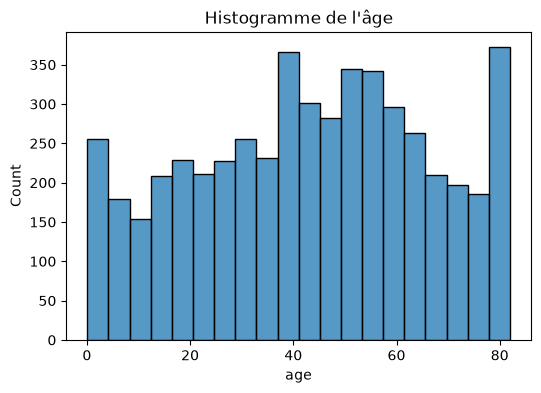

In [59]:
# Commençons par les features continues, pour se faire, on va commencer par analyser graphiquement
## Analysons la distribution
## Age
plt.figure(figsize=(6,4))
plt.title("Histogramme de l'âge")
sns.histplot(data=cont_features,x='age')
plt.show()

Ici, on constate qu'il y'a une bonne distribution,
On voit 2 groupes : pic de personnes vers 40 ans et 80

(prof pas énorme fan des graphiques de distributions)

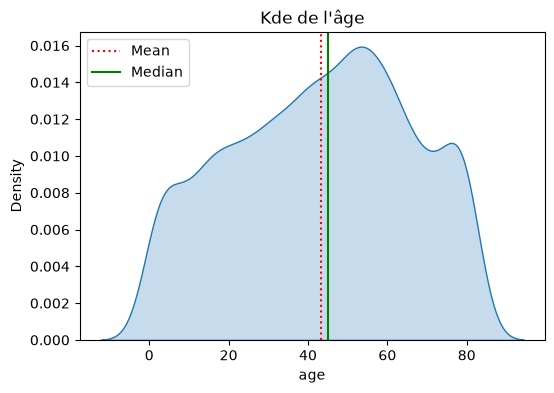

In [60]:
plt.figure(figsize=(6,4))
plt.title("Kde de l'âge")
sns.kdeplot(data=cont_features,x='age', fill=True) # kde = Kernel density estimation
plt.axvline(x=cont_features['age'].mean(),c="red",linestyle=":",label="Mean")   # Affichage de la valeur moyenne (barre verticale)
plt.axvline(x=cont_features['age'].median(),c="green",label="Median")  # Affichage de la valeur Medianne (barre verticale)
plt.legend(loc="upper left")
plt.show()

Les deux petites bosses questionne sur une bimodalité, on se pose la question : tiens, ce n'est pas normal

La bimodalité désigne une distribution de données qui présente deux modes, c'est-à-dire deux pics de fréquence distincts.

La présence de deux pics indique souvent que les observations proviennent de deux sous-populations différentes ou de deux mécanismes de génération des données.

Exemples :

Taille d'une population mélangeant hommes et femmes.
Revenus d'employés et de managers dans le même dataset.
Temps de réponse d'un système en mode normal et en mode dégradé.

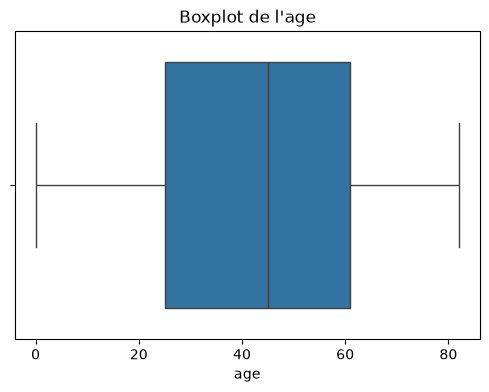

In [61]:
plt.figure(figsize=(6,4))
plt.title("Boxplot de l'age")
sns.boxplot(data=cont_features,x="age")
plt.show()

# Le boxplot est un graphique important, c'est une boite à moustache

Le Boxplot : (Toujours dans un intérêt d'analyse de distribution)

- Le boxplot apporte des infos en + utiles et intéressantes
- La barre verticale noire est la médiane
- Début de la boite 1er quartile, fin de la boite 3eme quartile
- Les barres extrêmes sont bien le maximum et le minimum :
    - Car il n'y a rien qui dépasse la règle de Teuki

Règle de Tukey  :
moustache inférieure = Q1 -1.5(Q3-Q1)   ------> Q3-Q1 = IQR  (écart interquartile)
moustache supérieure = Q3 + 1.5(Q3-Q1)

Dans le cas ou tt les valeurs sont à l'intérieur des valeurs de Tukey, les moustaches sont égales aux valeur max ou min, si une valeur dépasse ces valeurs théoriques, la moustache correspond à la valeur de tukey.

Exemple d'un cas ou les valeus sortent des moustaches ci dessous, toutes les valeurs en dehors sont considérées comme des outliers

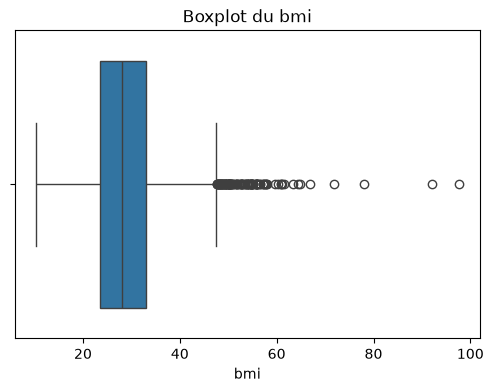

In [62]:
plt.figure(figsize=(6,4))
plt.title("Boxplot du bmi")
sns.boxplot(data=cont_features,x="bmi")
plt.show()

Les 2 grands types d'outliers :
=> Distinguer l'erreur d'encodage à ce qui s'écarte de la normalité mais qui est un échantillon comme un autre
1. age de 1142 => Valeur abhérentes (probablement une erreur de frappe) => à distinguer d'une valeur
2. Poids de 350 Kg => Valeur qui s'écarte beaucoup de la norme mais vrai donnée

## Que faire des outliers 
- On souhaite se débarasser des valeurs outliers afin de garder l'entraînement sur la norme pour avoir une prédiction de résultat dans la norme
- Dans le cas de la fraude fiscale, ce qu'on cherche c'est ce qui sort de la norme

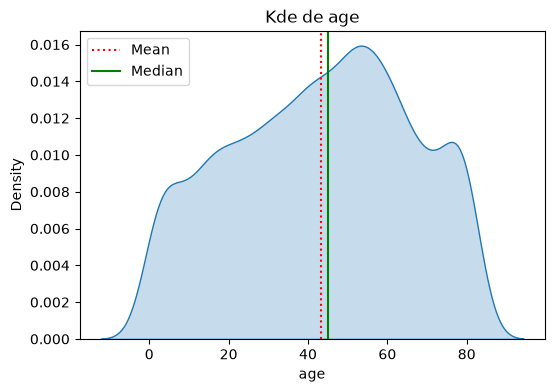

id
67       17.0
77       13.0
84       55.0
91       42.0
99       31.0
         ... 
72911    57.0
72914    19.0
72915    45.0
72918    53.0
72940     2.0
Name: age, Length: 5110, dtype: float64

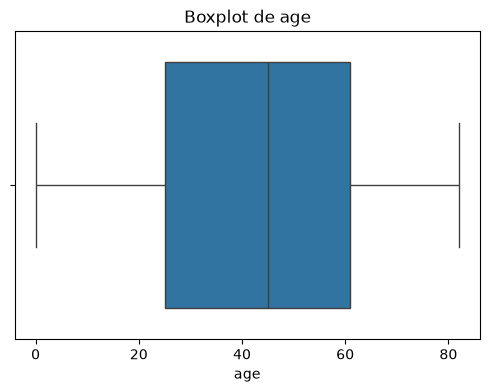

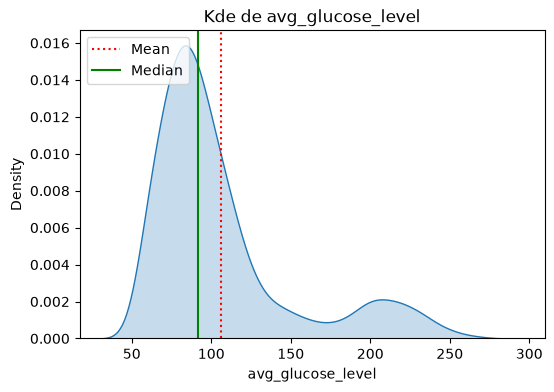

id
67        92.97
77        85.81
84        89.17
91        98.53
99       108.89
          ...  
72911    129.54
72914     90.57
72915    172.33
72918     62.55
72940    102.92
Name: avg_glucose_level, Length: 5110, dtype: float64

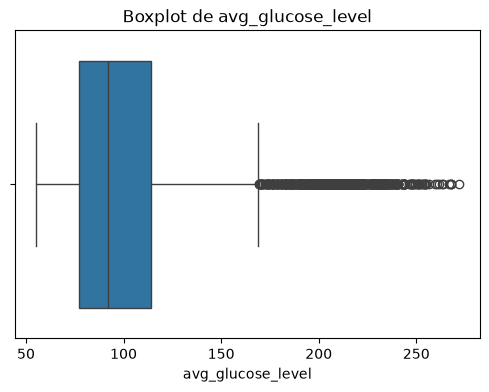

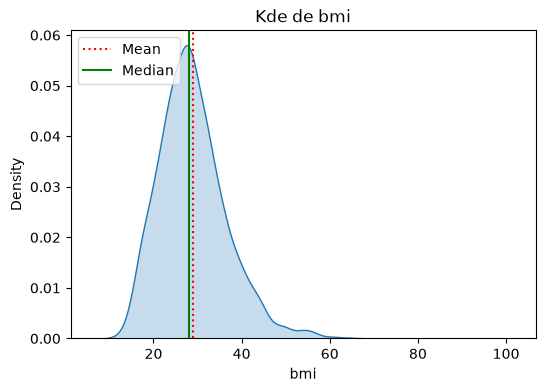

id
67        NaN
77       18.6
84       31.5
91       18.5
99       52.3
         ... 
72911    60.9
72914    24.2
72915    45.3
72918    30.3
72940    17.6
Name: bmi, Length: 5110, dtype: float64

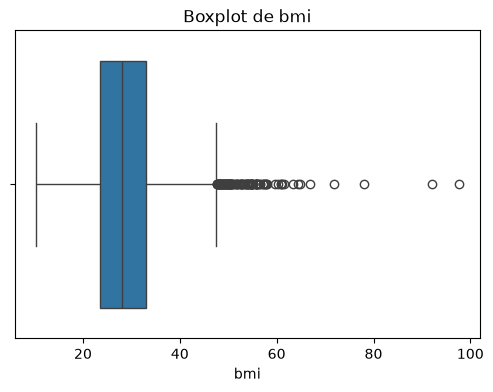

In [63]:
# Faisons une boucle pour afficher les graphs de KDe et boxplot de mes features continues

for col in cont_features.columns :
    plt.figure(figsize=(6,4))
    plt.title(f"Kde de {col}")
    sns.kdeplot(data=cont_features,x=col, fill=True) # kde = Kernel density estimation
    plt.axvline(x=cont_features[col].mean(),c="red",linestyle=":",label="Mean")   # Affichage de la valeur moyenne (barre verticale)
    plt.axvline(x=cont_features[col].median(),c="green",label="Median")  # Affichage de la valeur Medianne (barre verticale)
    plt.legend(loc="upper left")
    plt.show()

    display(cont_features[col])

    plt.figure(figsize=(6,4))
    plt.title(f"Boxplot de {col}")
    sns.boxplot(data=cont_features,x=col)
    plt.show()

Voilà pour l'analyse univarié des variable continues

## Analyse de la distribution sur les features univariées catégoriques



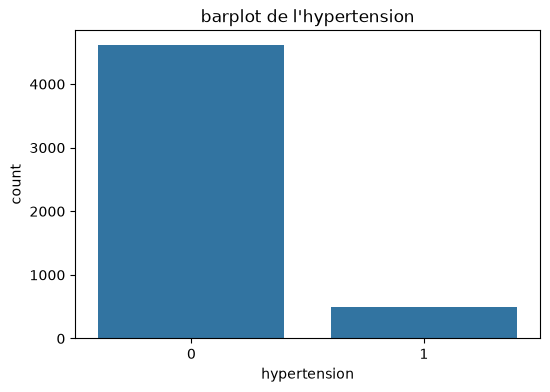

hypertension
0    4612
1     498
Name: count, dtype: int64

In [64]:
plt.figure(figsize=(6,4))
plt.title("barplot de l'hypertension")
sns.countplot(data=cat_features,x='hypertension')
plt.show()
cat_features['hypertension'].value_counts()

Dans mes datas, j'ai un déséquilibre dans la feature d'hypertension.

Pas un big deal, il est peut-être représentatif de la société

Dans les features => Aucun problème
Dans la target => Très Emmerdant

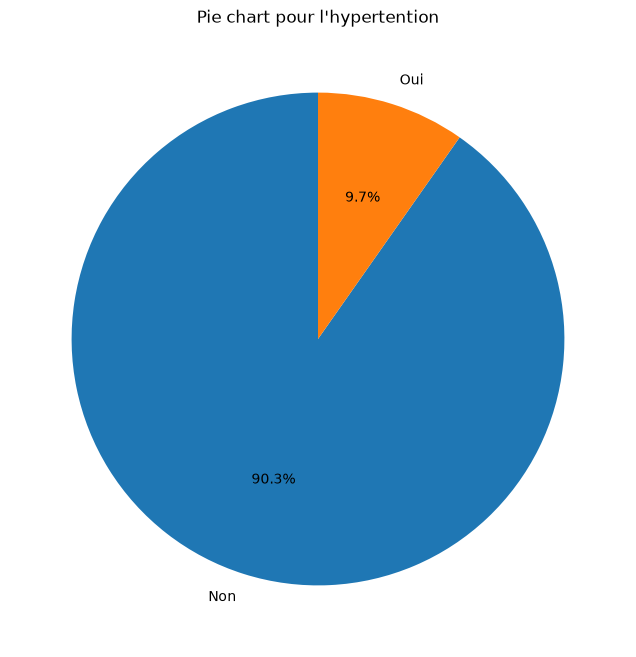

In [65]:
plt.figure(figsize=(12,8))
counts = df['hypertension'].value_counts()
plt.title("Pie chart pour l'hypertention")
plt.pie(counts,labels=['Non', 'Oui'],autopct='%1.1f%%',startangle=90)
plt.show()

# OU

# plt.figure(figsize=(12,8))

# plt.title("Pie chart pour l'hypertention")
# plt.pie(x=cat_features["hypertension"].value_counts(),labels=cat_features['hypertension'].unique(),autopct='%1.1f%%')
# plt.show()

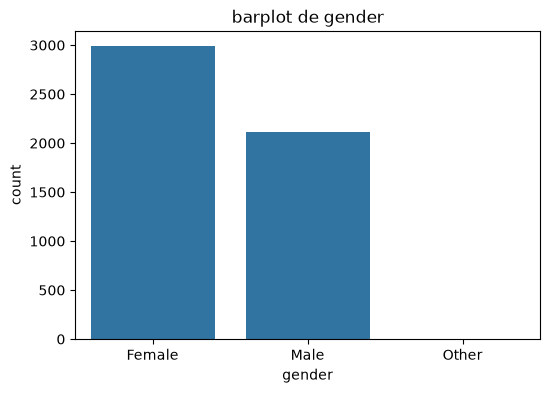

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

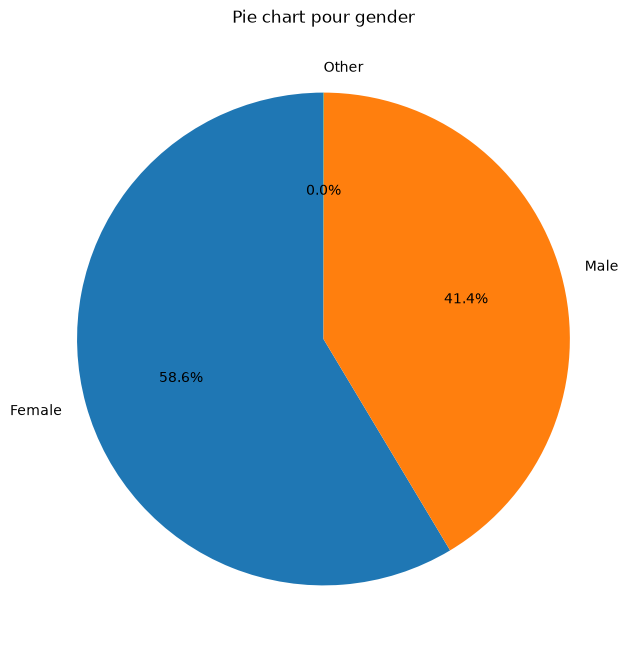

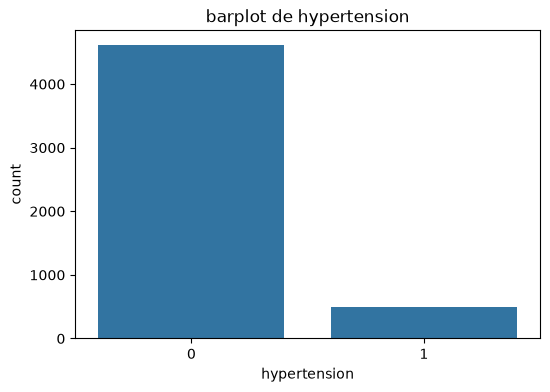

hypertension
0    4612
1     498
Name: count, dtype: int64

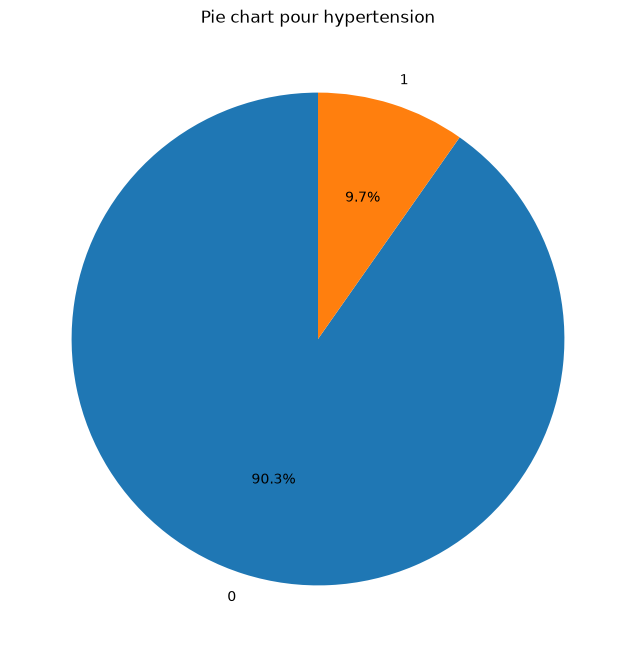

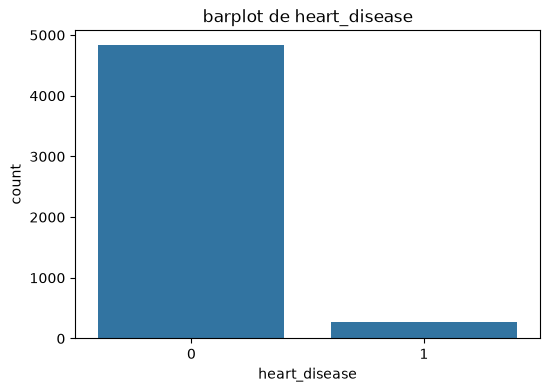

heart_disease
0    4834
1     276
Name: count, dtype: int64

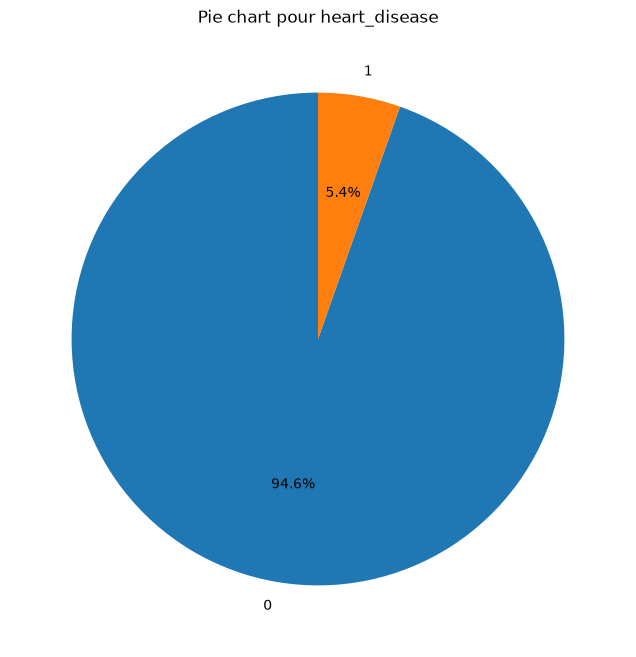

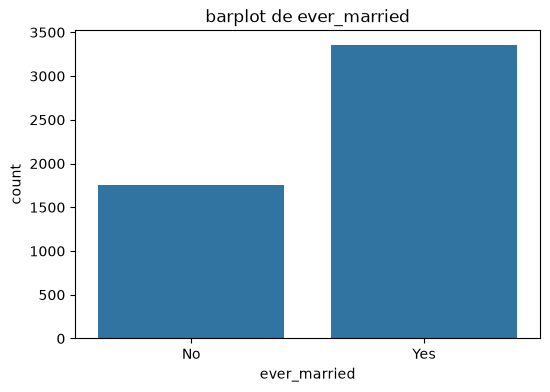

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

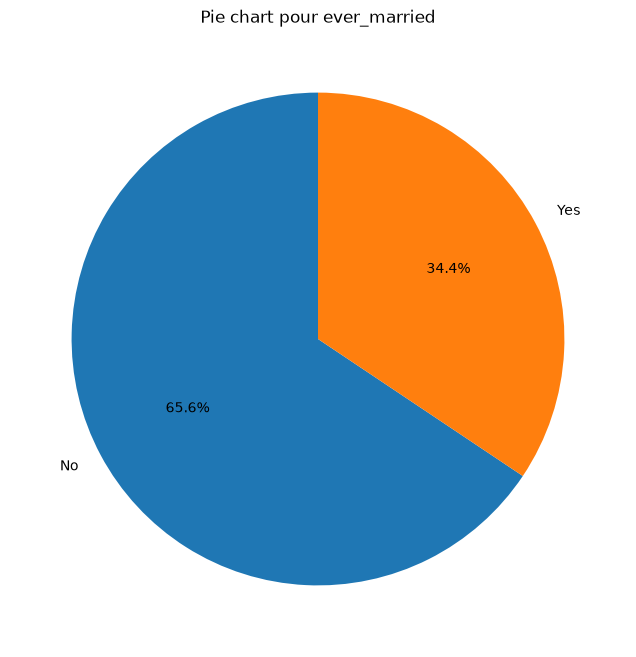

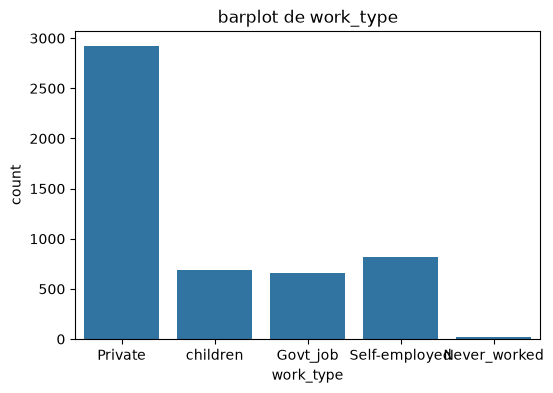

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

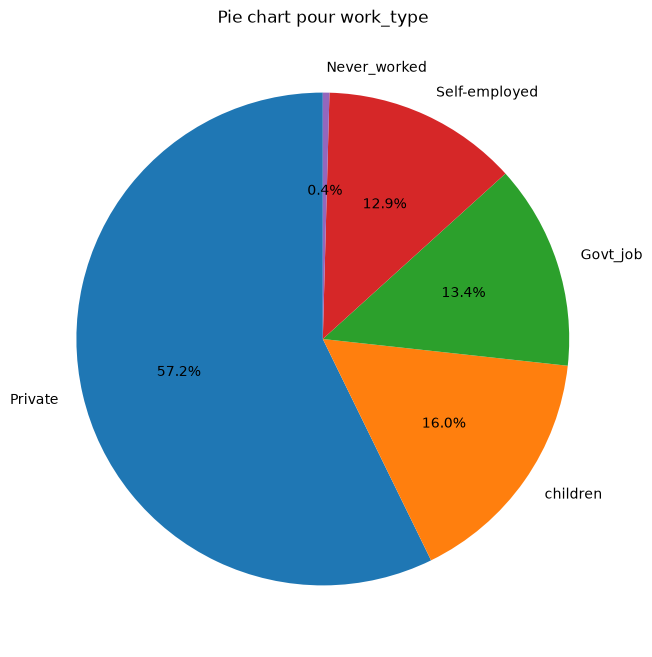

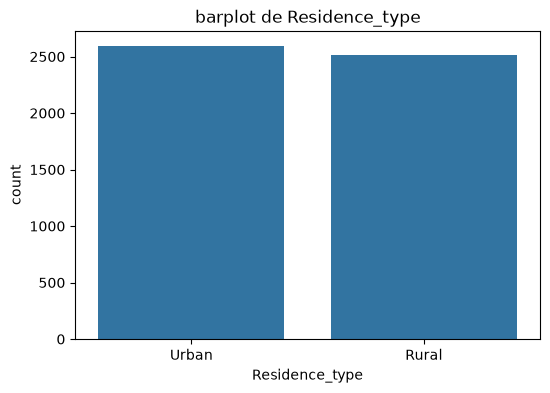

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

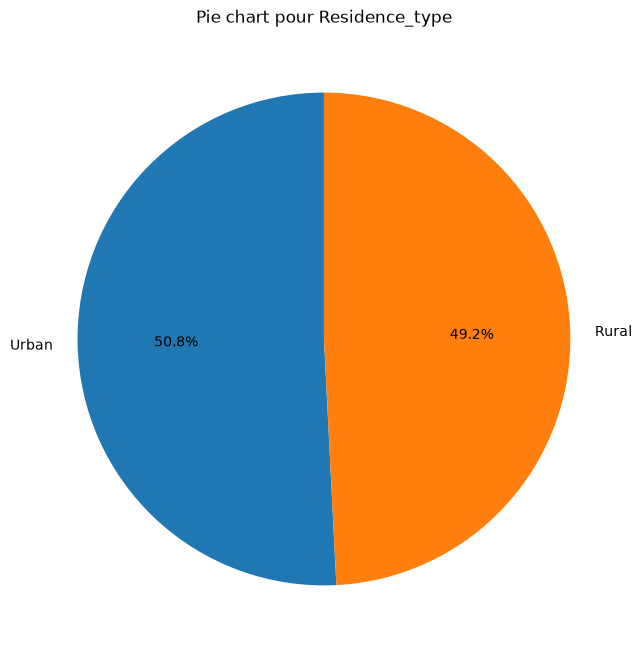

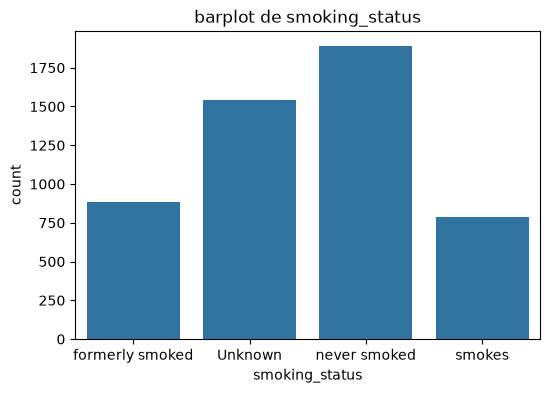

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

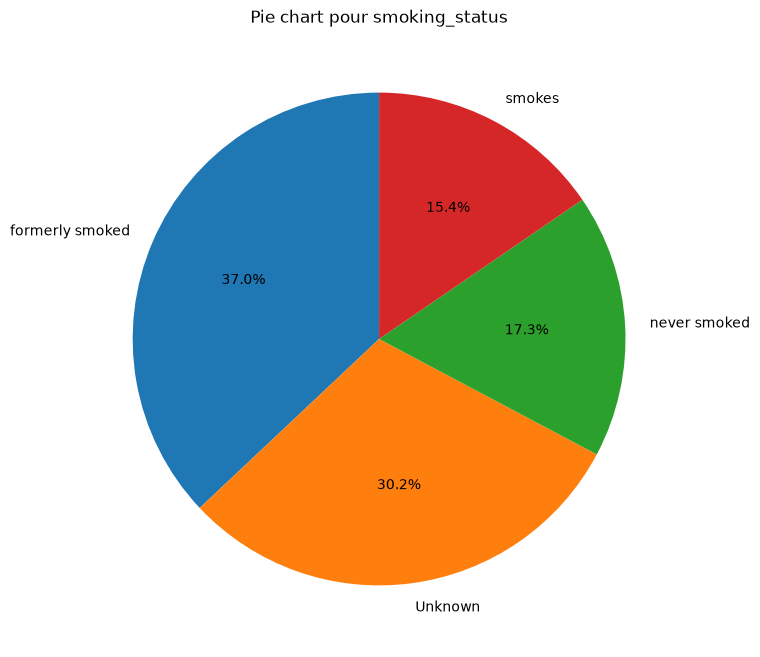

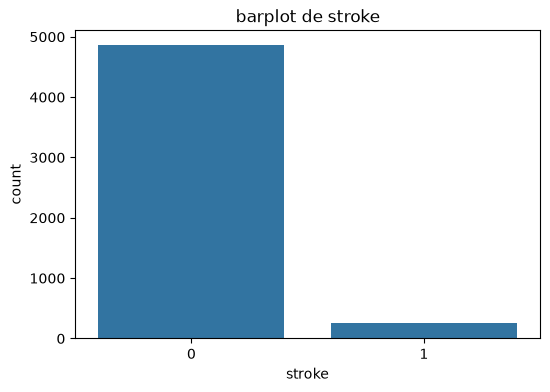

stroke
0    4861
1     249
Name: count, dtype: int64

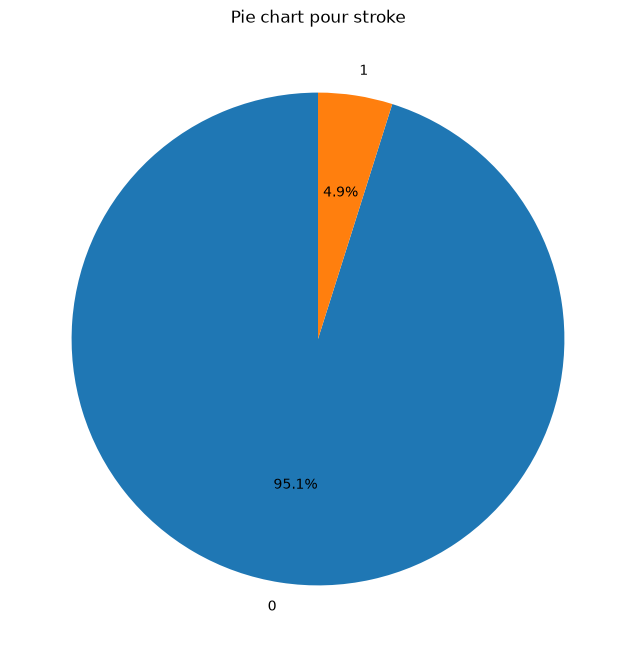

In [66]:
for col in cat_features.columns:
    plt.figure(figsize=(6,4))
    plt.title(f"barplot de {col}")
    sns.countplot(data=cat_features,x=col)
    plt.show()

    display(cat_features[col].value_counts())


    plt.figure(figsize=(12,8))
    counts = df[col].value_counts()
    plt.title(f"Pie chart pour {col}")
    plt.pie(counts,labels=cat_features[col].unique(),autopct='%1.1f%%',startangle=90)
    plt.show()


#### Analyse

##### Barplot de gender :
- Other est vrmt useless ici

##### Work type
- Never work sont trop peu nombreux donc risque de perturber mon modèle
- Soit supprimer soit transformer autrement


=> On considère faire du ML a partir de 50 échantillons min

##### Smoking status

- ok

##### Stroke
- Stroke est notre target, la distribution de yes/no est très dérangeante
- Dans notre cas, on veut éviter le faux négatif
    - Si le modèle se dit ok , 100% des gens ne feront jamais de stroke => Il a 97% de réussite mais il ne détecte aucun malade.

- Solutions :
    - OverSampling (SMOTE, Mets de vecteurs entre les échantillons catégorique de même type / Duplicata (bof,bof))
    - SubSampling ()

# Analyse bivariée

Assez simple, on projette tout sur la target

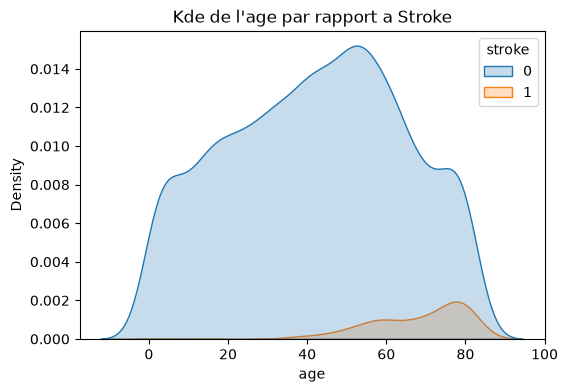

In [67]:
plt.figure(figsize=(6,4))
plt.title("Kde de l'age par rapport a Stroke")
sns.kdeplot(data=cont_features,x='age', fill=True,hue=df['stroke']) # Le paramètre hue permet de "ventiler" la distribution
plt.show()

Prbolème : Très peu d'échantillon pour 1 (stroke) par rapport à 0

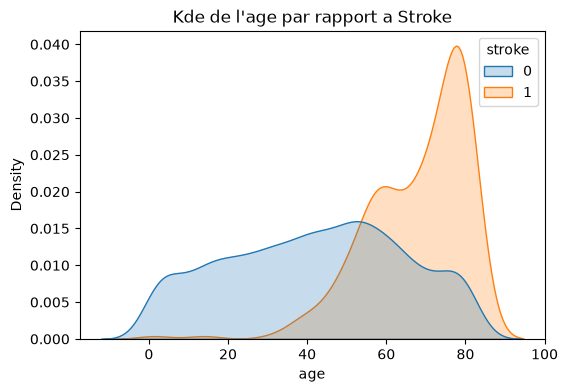

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4861.0,41.971545,22.291940,0.08,24.0,43.0,59.0,82.0
1,249.0,67.728193,12.727419,1.32,59.0,71.0,78.0,82.0


In [68]:
plt.figure(figsize=(6,4))
plt.title("Kde de l'age par rapport a Stroke")
sns.kdeplot(data=cont_features,x='age', fill=True,hue=df['stroke'],common_norm=False) # Le common_norm permet de faire la distribution intra_group
plt.show()

df.groupby("stroke")['age'].describe() # Ajouter la moyenne (describe mais la moyenne est intéressante) d'age selon le stroke

Ce qui nous intéresse dans ce graphique n'est pas la hauteur mais plutôt la répartition sur l'axe des x

Interpretation du graphique ci-dessus :
- à partir de 40 ans, le risque d'AVC augmente => Quand mon âge augmente, mon risque d'AVC augmente 

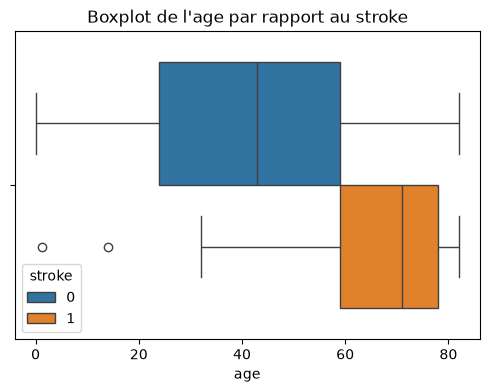

In [69]:
plt.figure(figsize=(6,4))
plt.title("Boxplot de l'age par rapport au stroke")
sns.boxplot(data=cont_features,x='age',hue=df["stroke"])
plt.show()

Pour que l'âge soit parfaitement discriminent, il faudrait que toute la boita à moustache soit décalé 
=> L'âge augmente le risque d'AVC mais ce n'est pas l'âge qui ser la "Cause" d'un AVC

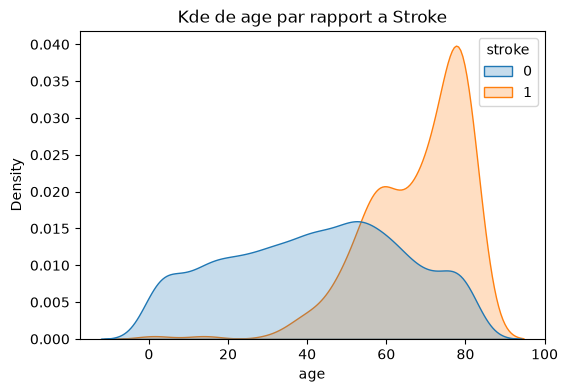

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4861.0,41.971545,22.291940,0.08,24.0,43.0,59.0,82.0
1,249.0,67.728193,12.727419,1.32,59.0,71.0,78.0,82.0


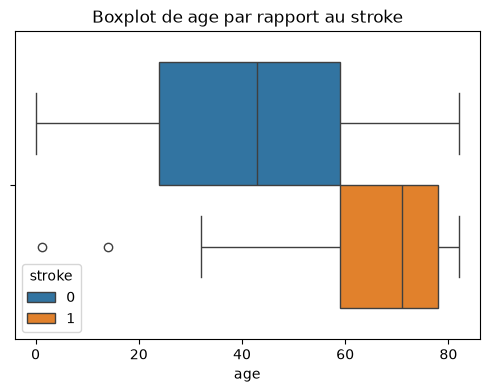

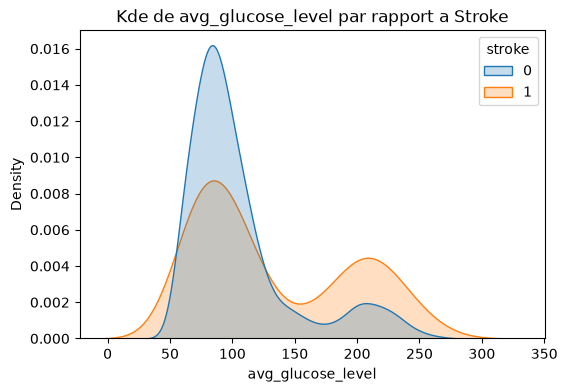

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4861.0,104.795513,43.846069,55.12,77.12,91.47,112.83,267.76
1,249.0,132.544739,61.921056,56.11,79.79,105.22,196.71,271.74


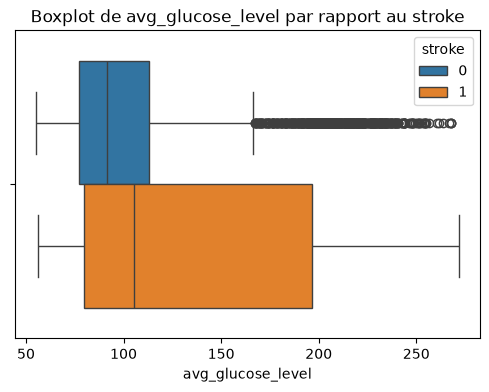

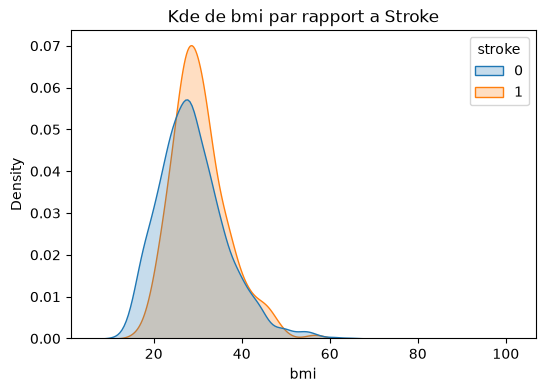

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4700.0,28.823064,7.908287,10.3,23.4,28.0,33.1,97.6
1,209.0,30.471292,6.329452,16.9,26.4,29.7,33.7,56.6


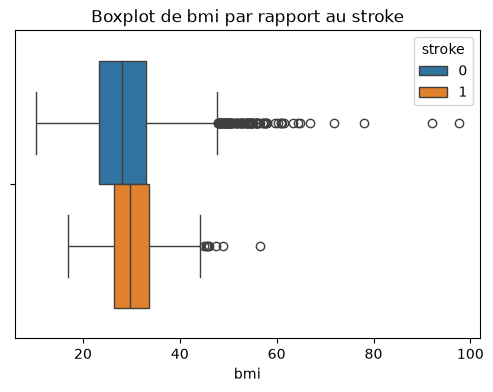

In [70]:
for col in cont_features.columns:

    #Kde
    plt.figure(figsize=(6,4))
    plt.title(f"Kde de {col} par rapport a Stroke")
    sns.kdeplot(data=cont_features,x=col, fill=True,hue=df['stroke'],common_norm=False) 
    plt.show()

    display(df.groupby("stroke")[col].describe())

    #Boxplot

    plt.figure(figsize=(6,4))
    plt.title(f"Boxplot de {col} par rapport au stroke")
    sns.boxplot(data=cont_features,x=col,hue=df["stroke"])
    plt.show()

### Jetons un coup d'oeuil aux graphs

#### Feature continues

1. Age 
    J'aime bien, on garde

2. Glucose 
    Pas fou fou, la distribution se ressemble (kde)
    Dans la liste potentielle des features à supp

3. BMI
    Pas discriminant, les courbes se chevauchent

CCL, si je devais garder une seule feature sur mes continues, je garderais l'âge

## Analyse bivariée pour les features catégoriques :



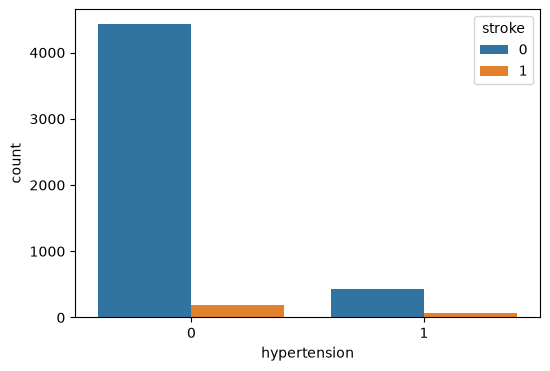

In [71]:
plt.figure(figsize=(6,4))
sns.countplot(data=cat_features,x='hypertension', hue=df['stroke'])
plt.show()


Voici ci-dessus pourquoi faire un countplot pour les features catégoriques n'est pas foufou, ce n'est pas très parlant.

Faisons qqch d'un peux mieux pour interpreter ces données :

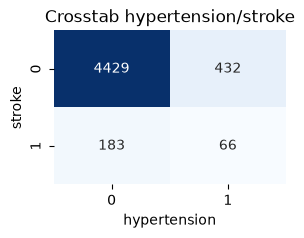

In [72]:
# Table de contingence
ct = pd.crosstab(index=cat_features['stroke'],columns=cat_features["hypertension"]) # Creation d'un crosstab avec pandas

plt.figure(figsize=(3,2))
plt.title("Crosstab hypertension/stroke")
sns.heatmap(ct,annot=True, cbar=False,cmap="Blues",fmt='.4g')
plt.show()

# PAS HYPER PARLANT POUR L'INSTANT


Une table de contingence (ou tableau croisé) est un tableau statistique qui permet d'étudier la relation entre deux variables qualitatives.

Elle montre combien d'individus appartiennent à chaque combinaison de catégories.

Une table de contingence permet :

Décrire des données

Visualiser la répartition des observations.
Comparer des groupes.

Étudier une éventuelle dépendance

Par exemple : la préférence pour le produit dépend-elle du sexe ?
On utilise souvent le test du Chi² (chi-carré) pour répondre à cette question.

Calculer des fréquences

Fréquences par ligne.
Fréquences par colonne.
Fréquences globales.

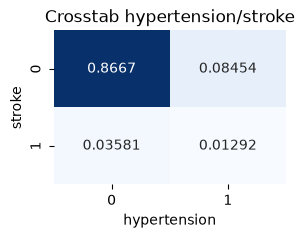

In [73]:
# Table de contingence
ct = pd.crosstab(index=cat_features['stroke'],columns=cat_features["hypertension"],normalize='all') # Normalisation

plt.figure(figsize=(3,2))
plt.title("Crosstab hypertension/stroke")
sns.heatmap(ct,annot=True, cbar=False,cmap="Blues",fmt='.4g')
plt.show()


Maintenant dans mon graphique, la somme de tout fait 100%

le normalize='all' permet de changer les chiffres de la qtité en %

Pas encore hyper fan de l'interpretion qu'on peux en tirer

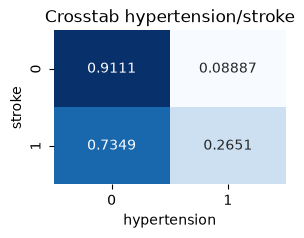

In [74]:
# Table de contingence
ct = pd.crosstab(index=cat_features['stroke'],columns=cat_features["hypertension"],normalize='index') # Normalisation = index

plt.figure(figsize=(3,2))
plt.title("Crosstab hypertension/stroke")
sns.heatmap(ct,annot=True, cbar=False,cmap="Blues",fmt='.4g')
plt.show()


Maintenant les 100% sont en index de stroke donc par ligne, intretation :

Sur 100% des gens qui ont fait un avc, j'ai 26% qui faisait de l'hypertention et 73% qui n'en faisaient pas
Sur 100% des gens qui n'ont pas fait d'avc, j'ai 91% qui n'avait pas d'hypertention et 8% non.



Ce qui m'interesse n'est pas de regarder les lignes mais de voir l'augmentation du risque : 
Donc on passe de 8% à 26%, le risque est 3x supérieur donc peut laisser penser qu'il y'a 3x plus de chance

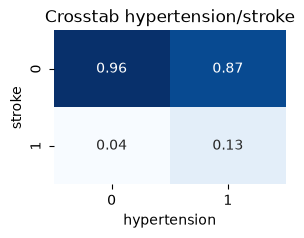

In [75]:
# Mettons les 100% en colonne :
# Table de contingence
ct = pd.crosstab(index=cat_features['stroke'],columns=cat_features["hypertension"],normalize='columns') # Normalisation = colonne

plt.figure(figsize=(3,2))
plt.title("Crosstab hypertension/stroke")
sns.heatmap(ct,annot=True, cbar=False,cmap="Blues",fmt='.2g')
plt.show()

Résultat similaire si on décide de normaliser sur l'index "stroke" ou sur l'hypertension

stroke,0,1
gender,,
Female,0.586916,0.566265
Male,0.412878,0.433735
Other,0.000206,0.000000


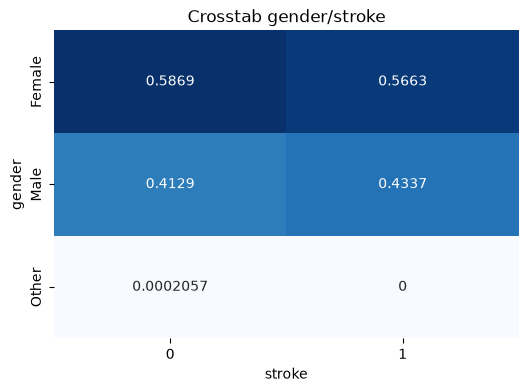

stroke,0,1
hypertension,,
0,0.911129,0.73494
1,0.088871,0.26506


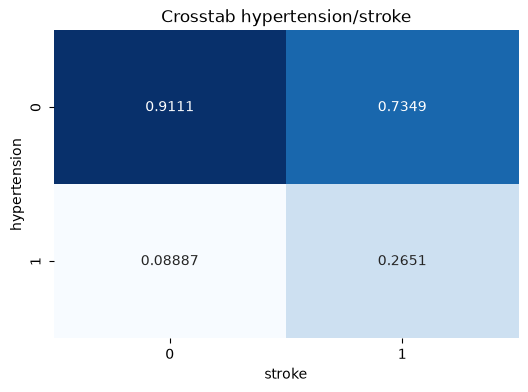

stroke,0,1
heart_disease,,
0,0.95289,0.811245
1,0.04711,0.188755


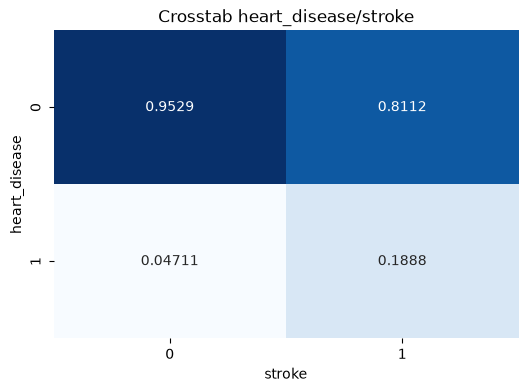

stroke,0,1
ever_married,,
No,0.355482,0.116466
Yes,0.644518,0.883534


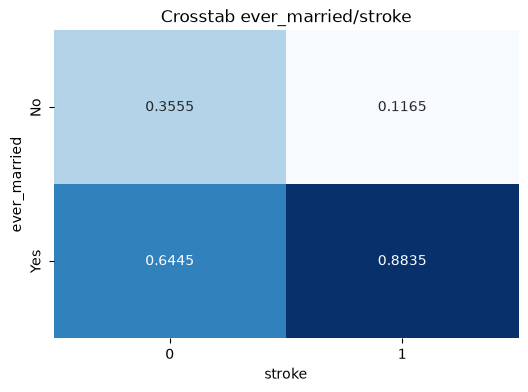

stroke,0,1
work_type,,
Govt_job,0.128369,0.132530
Never_worked,0.004526,0.000000
Private,0.571076,0.598394
Self-employed,0.155112,0.261044
children,0.140918,0.008032


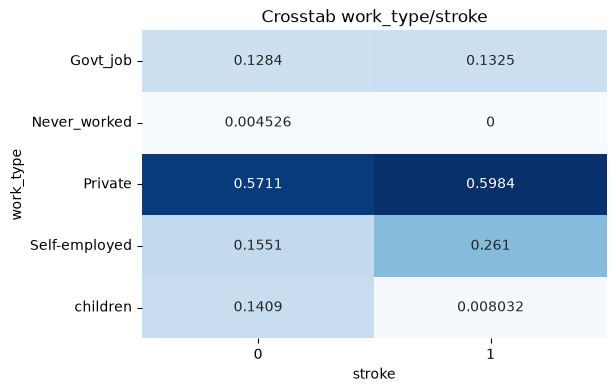

stroke,0,1
Residence_type,,
Rural,0.493726,0.457831
Urban,0.506274,0.542169


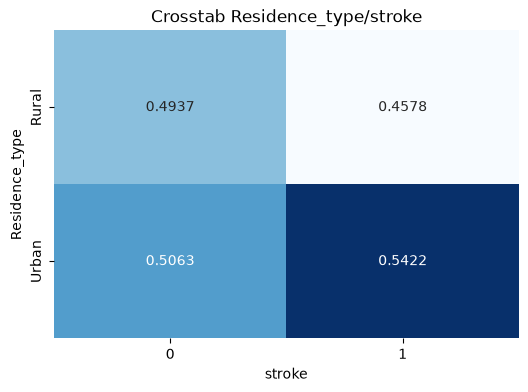

stroke,0,1
smoking_status,,
Unknown,0.307961,0.188755
formerly smoked,0.167661,0.281124
never smoked,0.370706,0.361446
smokes,0.153672,0.168675


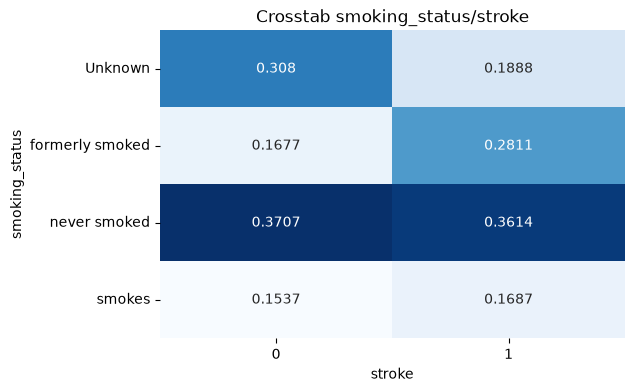

In [78]:
# Faisons la boucle pour toutesm es variables catégoriques :

for col in cat_features.columns :
    if col == 'stroke':
        continue
    # Table de contingence
    ct = pd.crosstab(index=cat_features[col],
                     columns=cat_features['stroke'],
                     normalize='columns') # Normalisation = index
    display(ct)
    plt.figure(figsize=(6,4))
    plt.title(f"Crosstab {col}/stroke")
    sns.heatmap(ct,annot=True, cbar=False,cmap="Blues",fmt='.4g')
    plt.show()


Interpretation :


1. Genre
    - Pas d'info pertinente

2. Hypertension
    - Vu au dessus, risque x3 pour les gens qui ont de l'hypertension

3. Hear disease
    - l y'a une correlation entre hear_disease et Avc x4

4. Ever married
    Pareil, risque qui augmente 

5. Work_type
    - Never_worked à 0 => petit problème et risque de biaiser nos données.
    - Être un enfant à tendance à réduire les avc
    - govt_job, private => ne bouge pas ou presque pas
    - Self-employed => petit facteur multiplicateur => augmentation de risque d'avc

6. Residence_type
    - Habiter en campagne ou en ville => très très léger, pas trop d'importance

7. Smoking_status
    - never_smoked => pas de grosse diff
    - Formely smoked : bizarre => C'est un peu erroné car probablement du au fait qu'après un AVC, les gens arrêtent de fumer


## Analyse multivariée

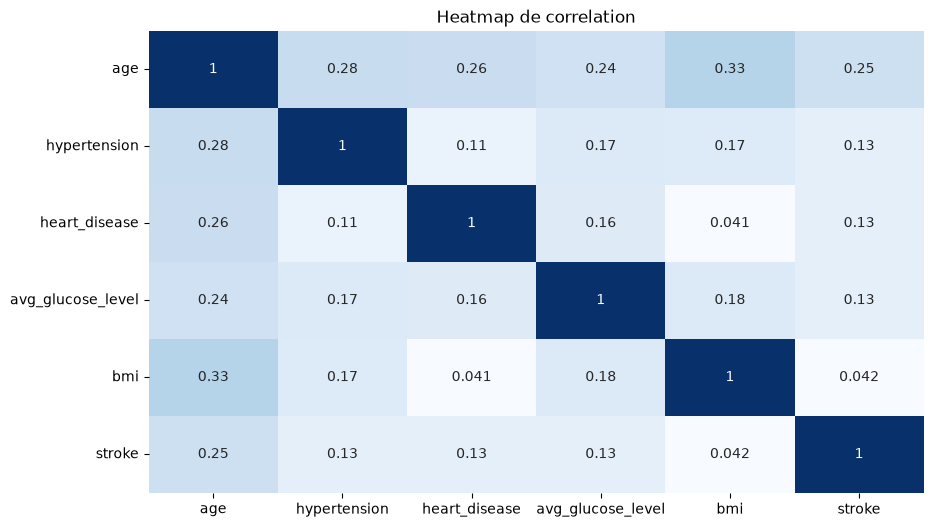

In [83]:
plt.figure(figsize=(10,6))
plt.title("Heatmap de correlation")
sns.heatmap(df.corr(numeric_only=True),cbar=False,annot=True,fmt='.2g',cmap="Blues")
plt.show()

Attention heart_disease et hypertension sont des catégoriques donc à prendre avec des pincettes, c'est juste que ils sont en type entier.

Interpretation :
L'age à quand même un point plus important (selon la target)

On va également regardé la correlation entre deux features, si deux features sont fortement correllées, cela créer de la "redondance" donc va influencer l'entraînement du modèle.
=> problème de multicolinéarité 
solution : on va capturer la variance des 4 variables en 2 variables (PCA)

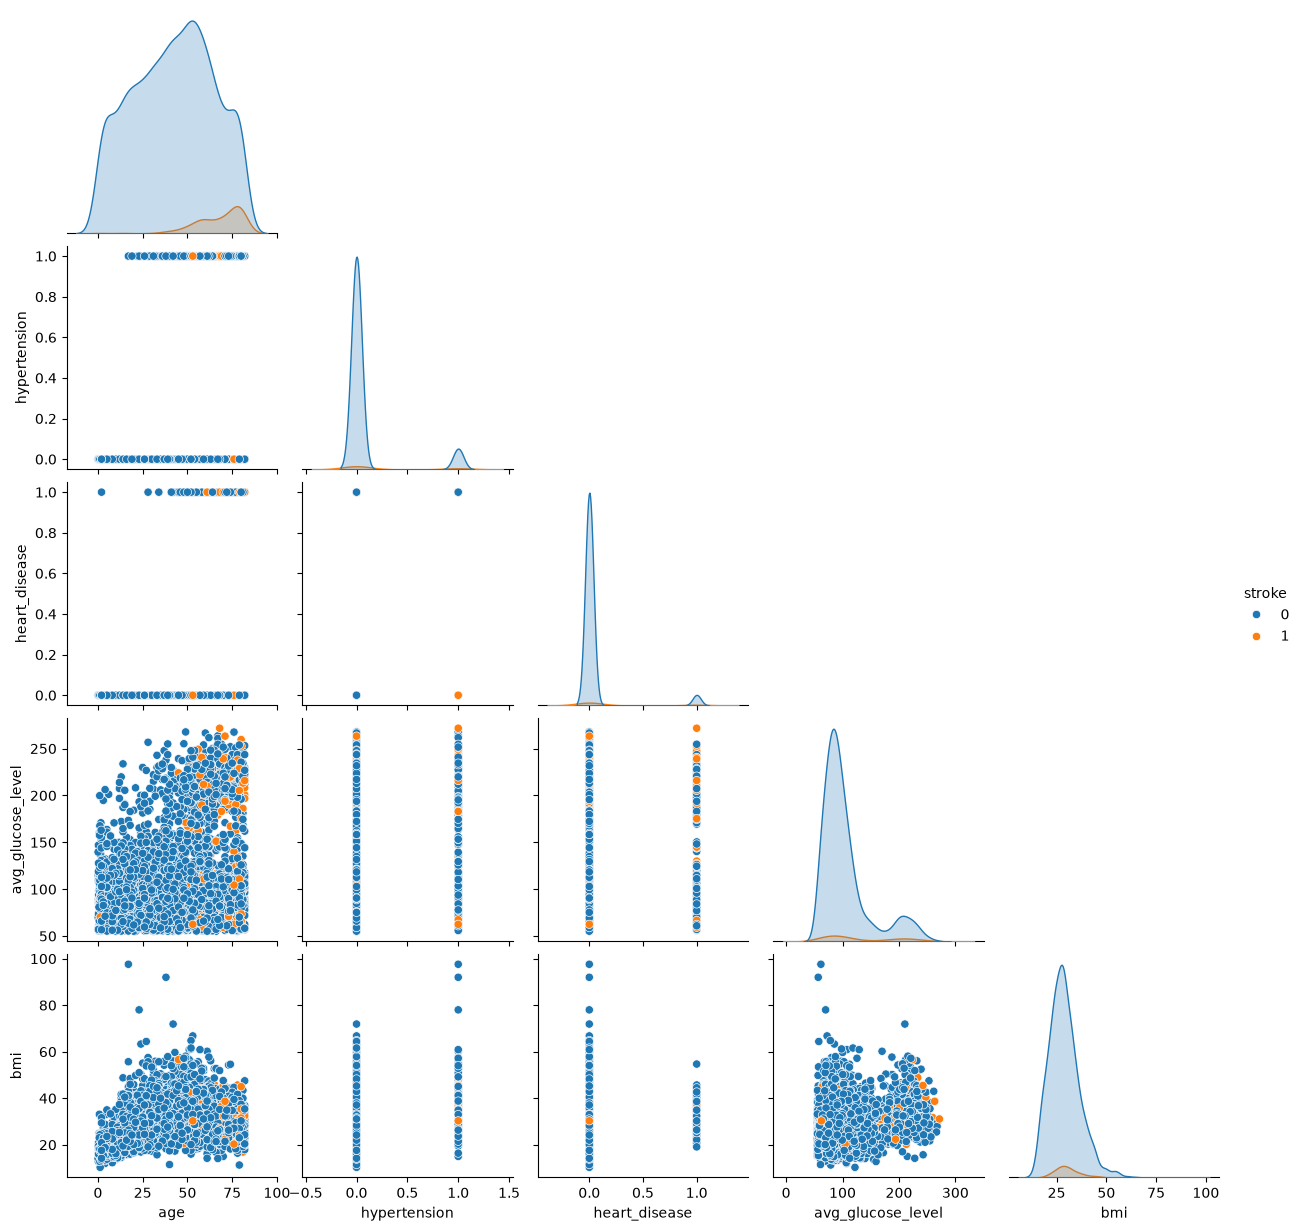

In [86]:
sns.pairplot(data=df,hue='stroke',corner=True)

Un pairplot : 
    - En diagonale : Distribution ventilée par classe (avec hue sur le stroke)
    - reste :  scatter plot : nuage de points (pour l'analyse de feature continu, intéressant)

Aucune info intéressante ici


CONCLUSION :
- Ce qui est important c'est de comprendre les datas pour savoir QUOI utiliser 
- Le ML est très vaste, il y'a beacoup de choses à appréhender